## Creates the **Grid File** of a specific country at a certain resolution ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

import sys

sys.path.insert(0, "../../Modules")

from utils import *

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

%matplotlib inline

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'

In [3]:
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

In [4]:
greece_nuts3 = gpd.read_file(f"../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding=enc)
greece_grid = gpd.read_file(f"../data/grid_index/grid_index.shp",  encoding=enc)
greece_wnv_cases = pd.read_csv('../data/GR_WNV_cases_grid_2010-2021_processed.csv', encoding = enc)


In [5]:
greece_nuts3.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
greece_lau1.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [7]:
greece_grid.head()

,PageName,PageNumber,geometry
0,A577,1,"POLYGON ((680010.000 4623806.000, 680010.000 4..."
1,A582,2,"POLYGON ((685010.000 4623806.000, 685010.000 4..."
2,B575,3,"POLYGON ((678010.000 4622806.000, 678010.000 4..."
3,B576,4,"POLYGON ((679010.000 4622806.000, 679010.000 4..."
4,B577,5,"POLYGON ((680010.000 4622806.000, 680010.000 4..."


In [8]:
greece_wnv_cases.head()

,age,sex,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code
0,75,f,2010-07-28,2010,7,28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307
1,78,m,2010-07-22,2010,7,22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242
2,70,f,2010-07-24,2010,7,24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297
3,74,m,2010-07-30,2010,7,30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305
4,19,f,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336


In [9]:
greece_nuts3 = greece_nuts3.to_crs(epsg=4326)
greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_grid = greece_grid.to_crs(epsg=4326)

In [10]:
greece_lau1.drop(columns=['KWD_YPES'], inplace = True)
greece_lau1.drop(greece_lau1[greece_lau1['NAME'] == 'Άθως'].index, inplace = True)
greece_lau1.rename(columns={"NAME": "LAU1_NAME", "geometry": "lau1_geom"}, inplace = True)
greece_lau1.set_geometry("lau1_geom", inplace = True)
greece_lau1['lau1_centroid'] = greece_lau1['lau1_geom'].centroid
greece_lau1['lau1_rpoint'] = greece_lau1['lau1_geom'].representative_point()
greece_lau1.reset_index(drop=True, inplace=True)

greece_nuts3.rename(columns={"geometry": "nuts3_geom"}, inplace = True)
greece_nuts3.set_geometry("nuts3_geom", inplace = True)

greece_grid.drop(columns=['PageNumber'], inplace=True)
greece_grid['cell_rpoint'] = greece_grid['geometry'].representative_point()
greece_grid.set_axis(['cell_code', 'geometry', 'cell_rpoint'], axis=1, inplace=True)

C:\Users\dimit\AppData\Local\Temp/ipykernel_28012/1467516429.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  greece_lau1['lau1_centroid'] = greece_lau1['lau1_geom'].centroid


In [11]:
print(f'greece_nuts3 CRS: {greece_nuts3.crs}')
print(f'greece_lau1 CRS: {greece_lau1.crs}')
print(f'greece_index CRS: {greece_grid.crs}')

greece_nuts3 CRS: epsg:4326
greece_lau1 CRS: epsg:4326
greece_index CRS: epsg:4326


<AxesSubplot:>

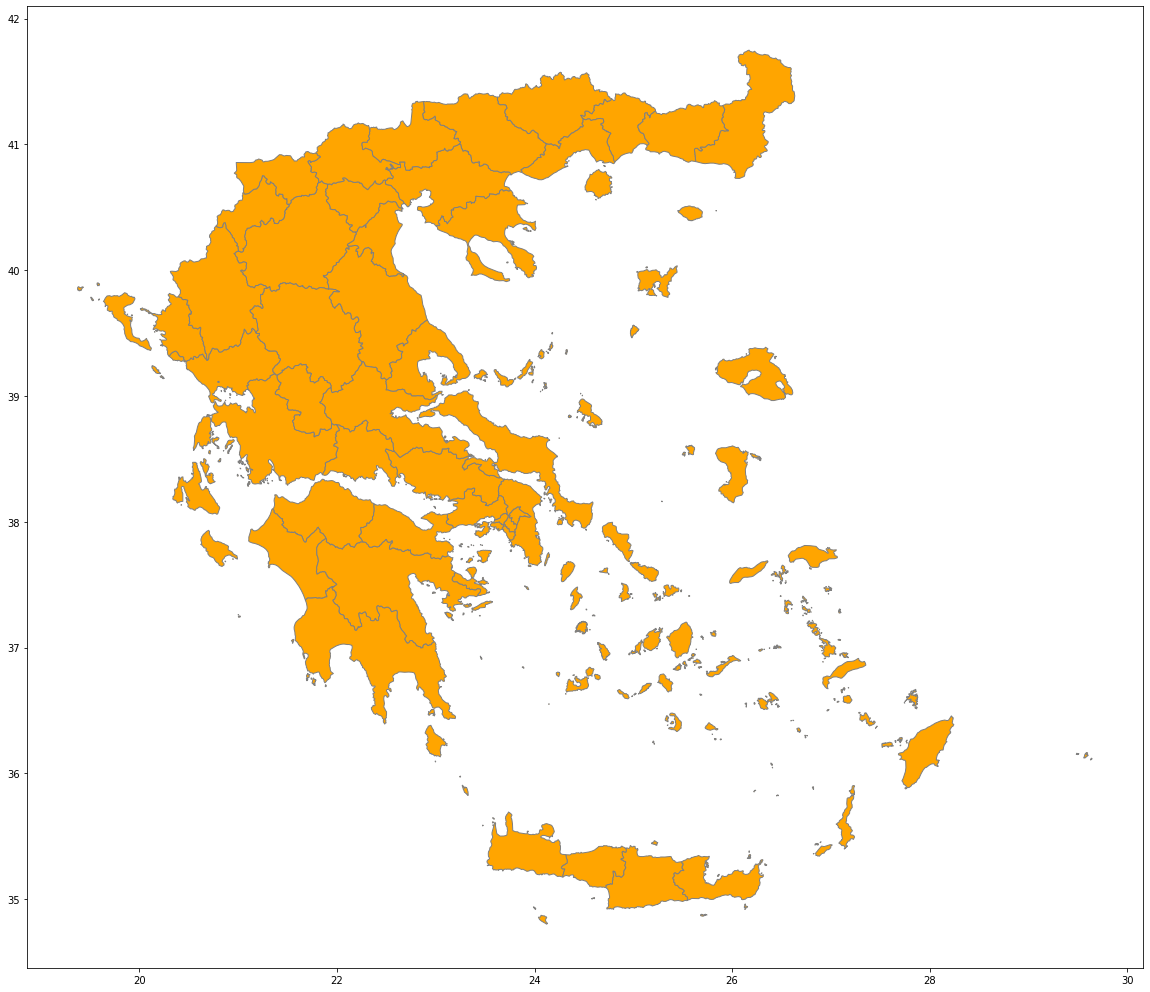

In [12]:
greece_nuts3.plot(facecolor="none", edgecolor='grey', figsize=(20, 20), color='orange')

<AxesSubplot:>

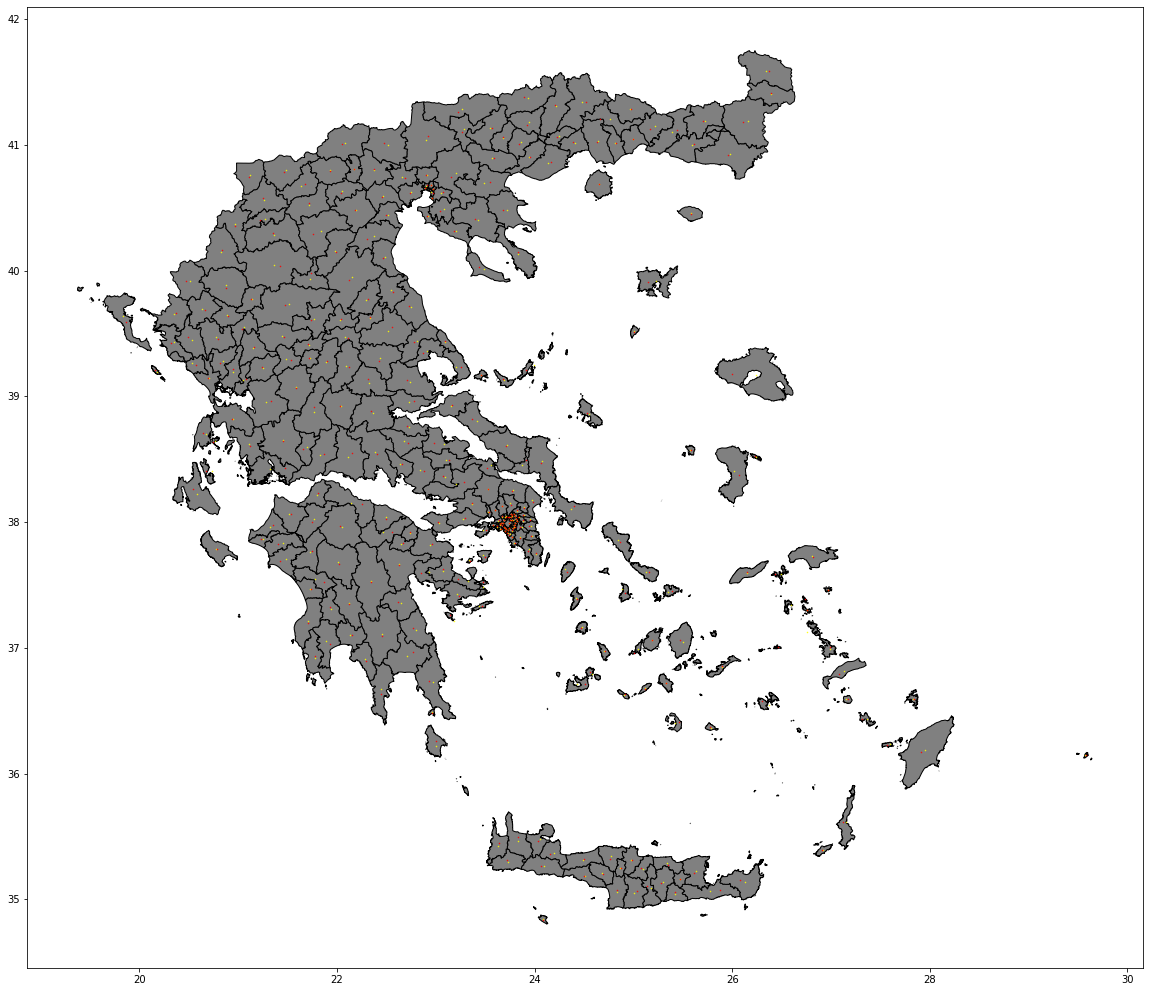

In [13]:
ax = greece_lau1.plot(facecolor="none", edgecolor='black', figsize=(20, 20), color='grey')
greece_lau1['lau1_centroid'].plot(markersize=.25, ax=ax, color='yellow')
greece_lau1['lau1_rpoint'].plot(markersize=.25, ax=ax, color='red')

<AxesSubplot:>

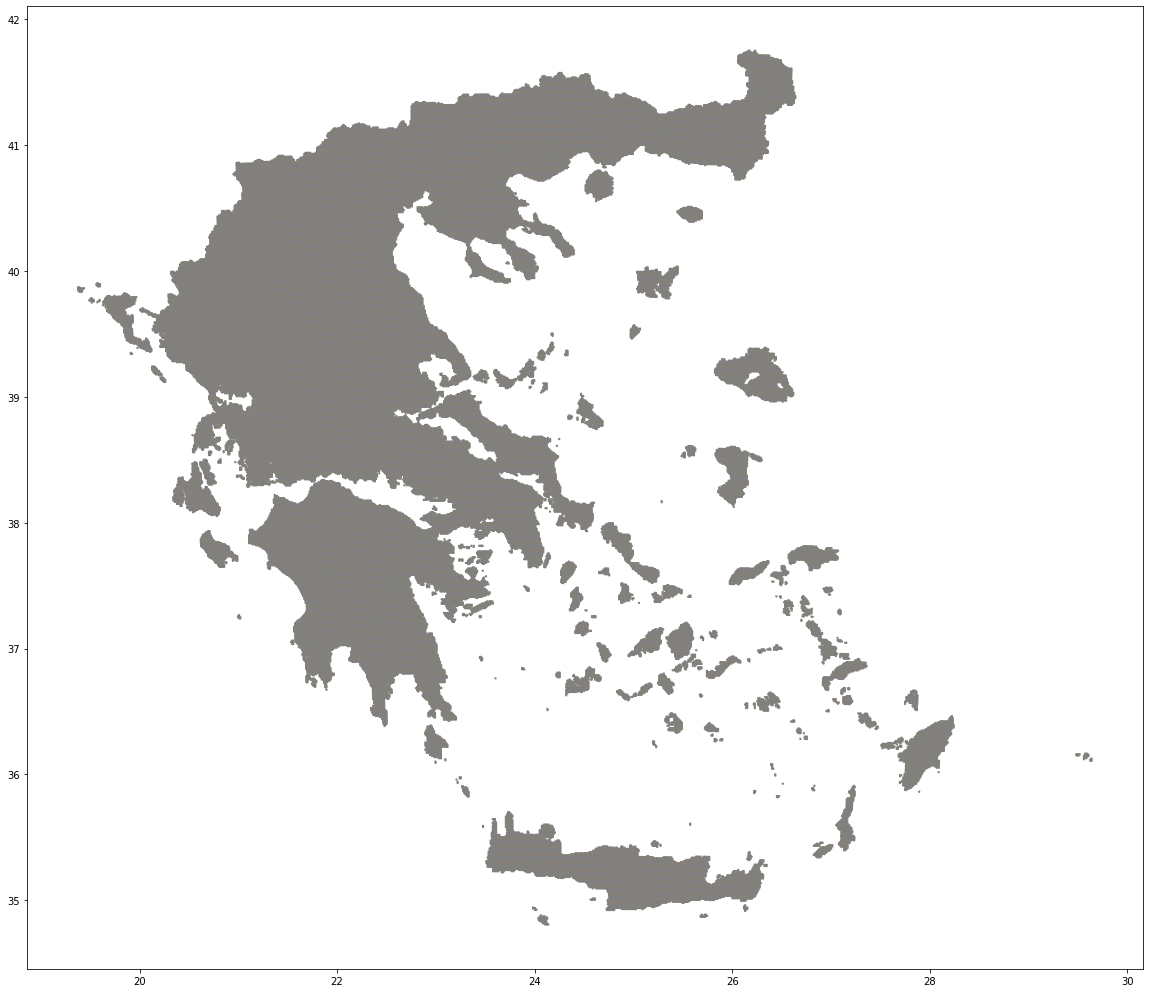

In [14]:
greece_grid.plot(facecolor="none", edgecolor='grey', figsize=(20, 20), color='orange')

In [15]:
greece_lau1.set_geometry("lau1_rpoint", inplace = True)
greece_nuts3 = greece_nuts3.to_crs(epsg=4326)
greece_lau1 = greece_lau1.to_crs(epsg=4326)

greece_gdf = greece_lau1.sjoin(greece_nuts3, predicate="within", how = "left")
greece_gdf.head()

,LAU1_NAME,lau1_geom,lau1_centroid,lau1_rpoint,index_right,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,Αμυνταίου,"POLYGON ((21.70746 40.85172, 21.70955 40.85119...",POINT (21.63479 40.67528),POINT (21.67171 40.68676),30,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL53,Dytiki Makedonia,Δυτική Μακεδονία,EL533,Florina,Φλώρινα,3.0,3,3
1,Άκτιου - Βόνιτσας,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38...",POINT (20.95158 38.82289),POINT (20.93655 38.81891),41,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL63,Dytiki Elláda,Δυτική Ελλάδα,EL631,Aitoloakarnania,Αιτωλοακαρνανία,2.0,3,1
2,Άνδρου,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37...",POINT (24.84814 37.85801),POINT (24.86216 37.84094),11,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL42,Notio Aigaio,Νότιο Αιγαίο,EL422,"Andros, Thira, Kea, Milos, Mykonos, Naxos, Par...","Άνδρος, Θήρα, Κέα, Μήλος, Μύκονος, Νάξος, Πάρο...",2.0,3,1
3,Άργους - Μυκηνών,"POLYGON ((22.52084 37.83857, 22.52111 37.83829...",POINT (22.62532 37.66339),POINT (22.62833 37.65584),49,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL651,"Argolida, Arkadia","Αργολίδα, Αρκαδία",3.0,3,1
4,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344...",POINT (21.92931 40.79799),POINT (21.93215 40.79303),24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2


In [16]:
greece_gdf.shape

(325, 19)

In [17]:
greece_gdf.drop(columns = ['lau1_centroid',	'lau1_rpoint', 'index_right', 'CNTR_CODE', 'CNTR_NAME', 'NUTS1_LATN', 'NUTS2_LATN', 'NUTS3_LATN'], inplace = True)

In [18]:
greece_gdf.set_geometry('lau1_geom', inplace = True)
greece_grid.set_geometry('cell_rpoint', inplace = True)

In [19]:
greece_gdf = greece_gdf.to_crs(epsg=4326)
greece_grid = greece_grid.to_crs(epsg=4326)

In [20]:
greece_grid = greece_grid.sjoin_nearest(greece_gdf, how='left', max_distance=0.01, distance_col='dist')


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\array.py:340: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [21]:
greece_grid.head()

,cell_code,geometry,cell_rpoint,index_right,LAU1_NAME,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,dist
0,A577,"POLYGON ((26.16678 41.74822, 26.16708 41.75722...",POINT (26.17294 41.75261),226.0,Ορεστιάδας,EL5,Βόρεια Ελλάδα,EL51,"Aνατολική Μακεδονία, Θράκη",EL511,Έβρος,4.0,2.0,1.0,0.004115
1,A582,"POLYGON ((26.22687 41.74707, 26.22718 41.75607...",POINT (26.23304 41.75146),226.0,Ορεστιάδας,EL5,Βόρεια Ελλάδα,EL51,"Aνατολική Μακεδονία, Θράκη",EL511,Έβρος,4.0,2.0,1.0,0.004394
2,B575,"POLYGON ((26.14244 41.73967, 26.14274 41.74867...",POINT (26.14860 41.74406),226.0,Ορεστιάδας,EL5,Βόρεια Ελλάδα,EL51,"Aνατολική Μακεδονία, Θράκη",EL511,Έβρος,4.0,2.0,1.0,0.003853
3,B576,"POLYGON ((26.15446 41.73945, 26.15476 41.74845...",POINT (26.16062 41.74384),226.0,Ορεστιάδας,EL5,Βόρεια Ελλάδα,EL51,"Aνατολική Μακεδονία, Θράκη",EL511,Έβρος,4.0,2.0,1.0,0.000000
4,B577,"POLYGON ((26.16648 41.73922, 26.16678 41.74822...",POINT (26.17264 41.74361),226.0,Ορεστιάδας,EL5,Βόρεια Ελλάδα,EL51,"Aνατολική Μακεδονία, Θράκη",EL511,Έβρος,4.0,2.0,1.0,0.000000


In [22]:
greece_grid.shape

(141365, 15)

In [23]:
greece_grid_nans = greece_grid[greece_grid['index_right'].isna()].copy()

In [24]:
greece_grid_nans.set_geometry('geometry', inplace = True)

<AxesSubplot:>

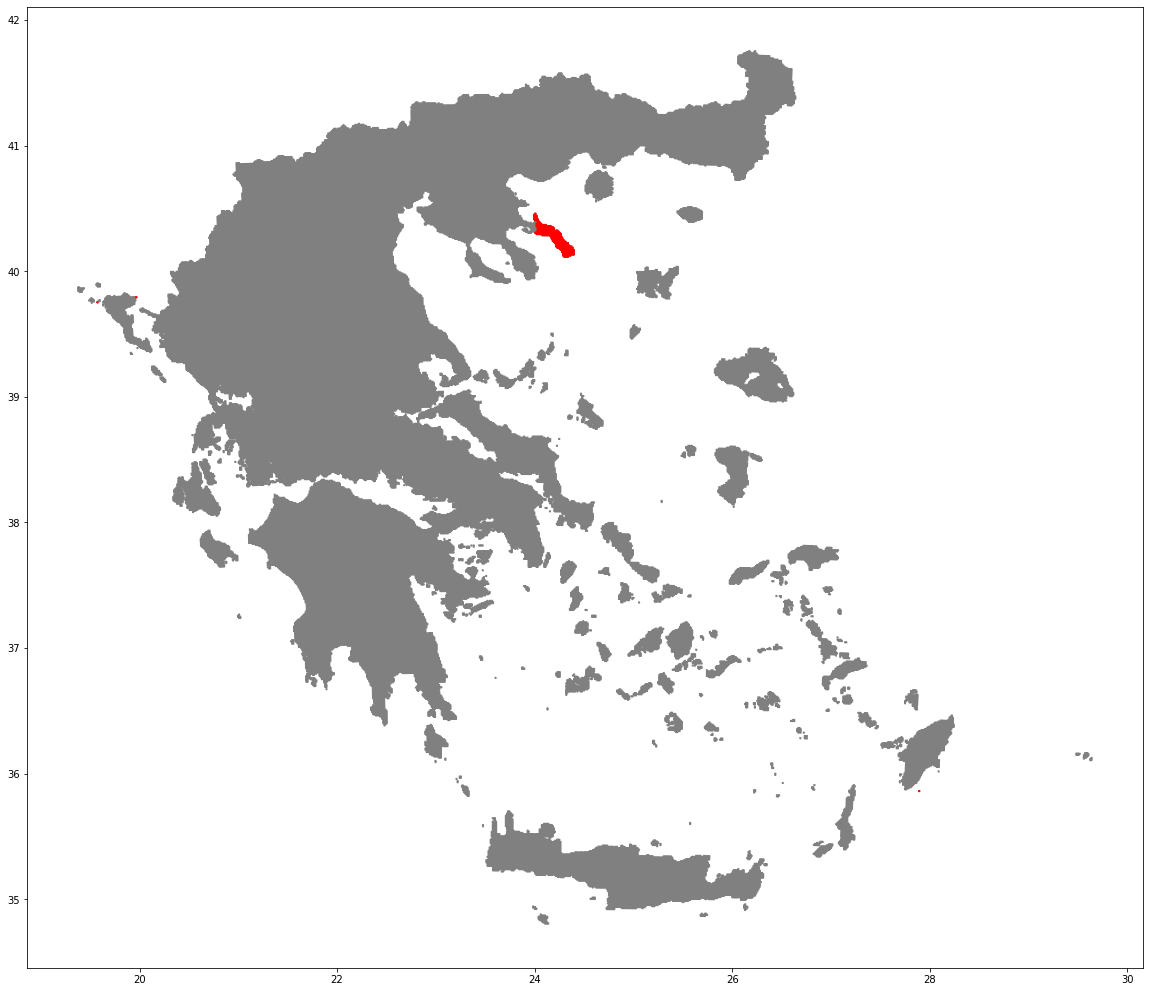

In [25]:
ax = greece_grid['geometry'].plot(facecolor="none", edgecolor='grey', figsize=(20, 20), color='grey')

greece_grid_nans.plot(facecolor="none", edgecolor='red', ax = ax , color='red')

In [26]:
greece_grid_nans.shape

(398, 15)

In [27]:
describe_dataframe(greece_grid)

,Column,Missing
0,cell_code,0.0000
1,geometry,0.0000
2,cell_rpoint,0.0000
3,index_right,0.2815
4,LAU1_NAME,0.2815
5,NUTS1_ID,0.2815
6,NUTS1_NAME,0.2815
7,NUTS2_ID,0.2815
8,NUTS2_NAME,0.2815
9,NUTS3_ID,0.2815


In [28]:
greece_grid.dropna(how='any', inplace = True)

In [29]:
describe_dataframe(greece_grid)

,Column,Missing
0,cell_code,0.0
1,geometry,0.0
2,cell_rpoint,0.0
3,index_right,0.0
4,LAU1_NAME,0.0
5,NUTS1_ID,0.0
6,NUTS1_NAME,0.0
7,NUTS2_ID,0.0
8,NUTS2_NAME,0.0
9,NUTS3_ID,0.0


In [30]:
greece_grid.dist.max()

0.009998383223710815

<AxesSubplot:>

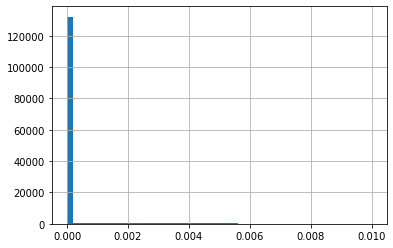

In [31]:
greece_grid.dist.hist(bins = 50)

In [32]:
greece_grid.reset_index(drop = True, inplace = True)

In [33]:
greece_grid.set_geometry('geometry', inplace = True)

In [34]:
greece_grid.drop(columns = ['cell_rpoint', 'index_right', 'dist'], inplace = True)

In [35]:
greece_grid['centroid'] = greece_grid['geometry'].centroid

C:\Users\dimit\AppData\Local\Temp/ipykernel_28012/830613437.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  greece_grid['centroid'] = greece_grid['geometry'].centroid


<AxesSubplot:>

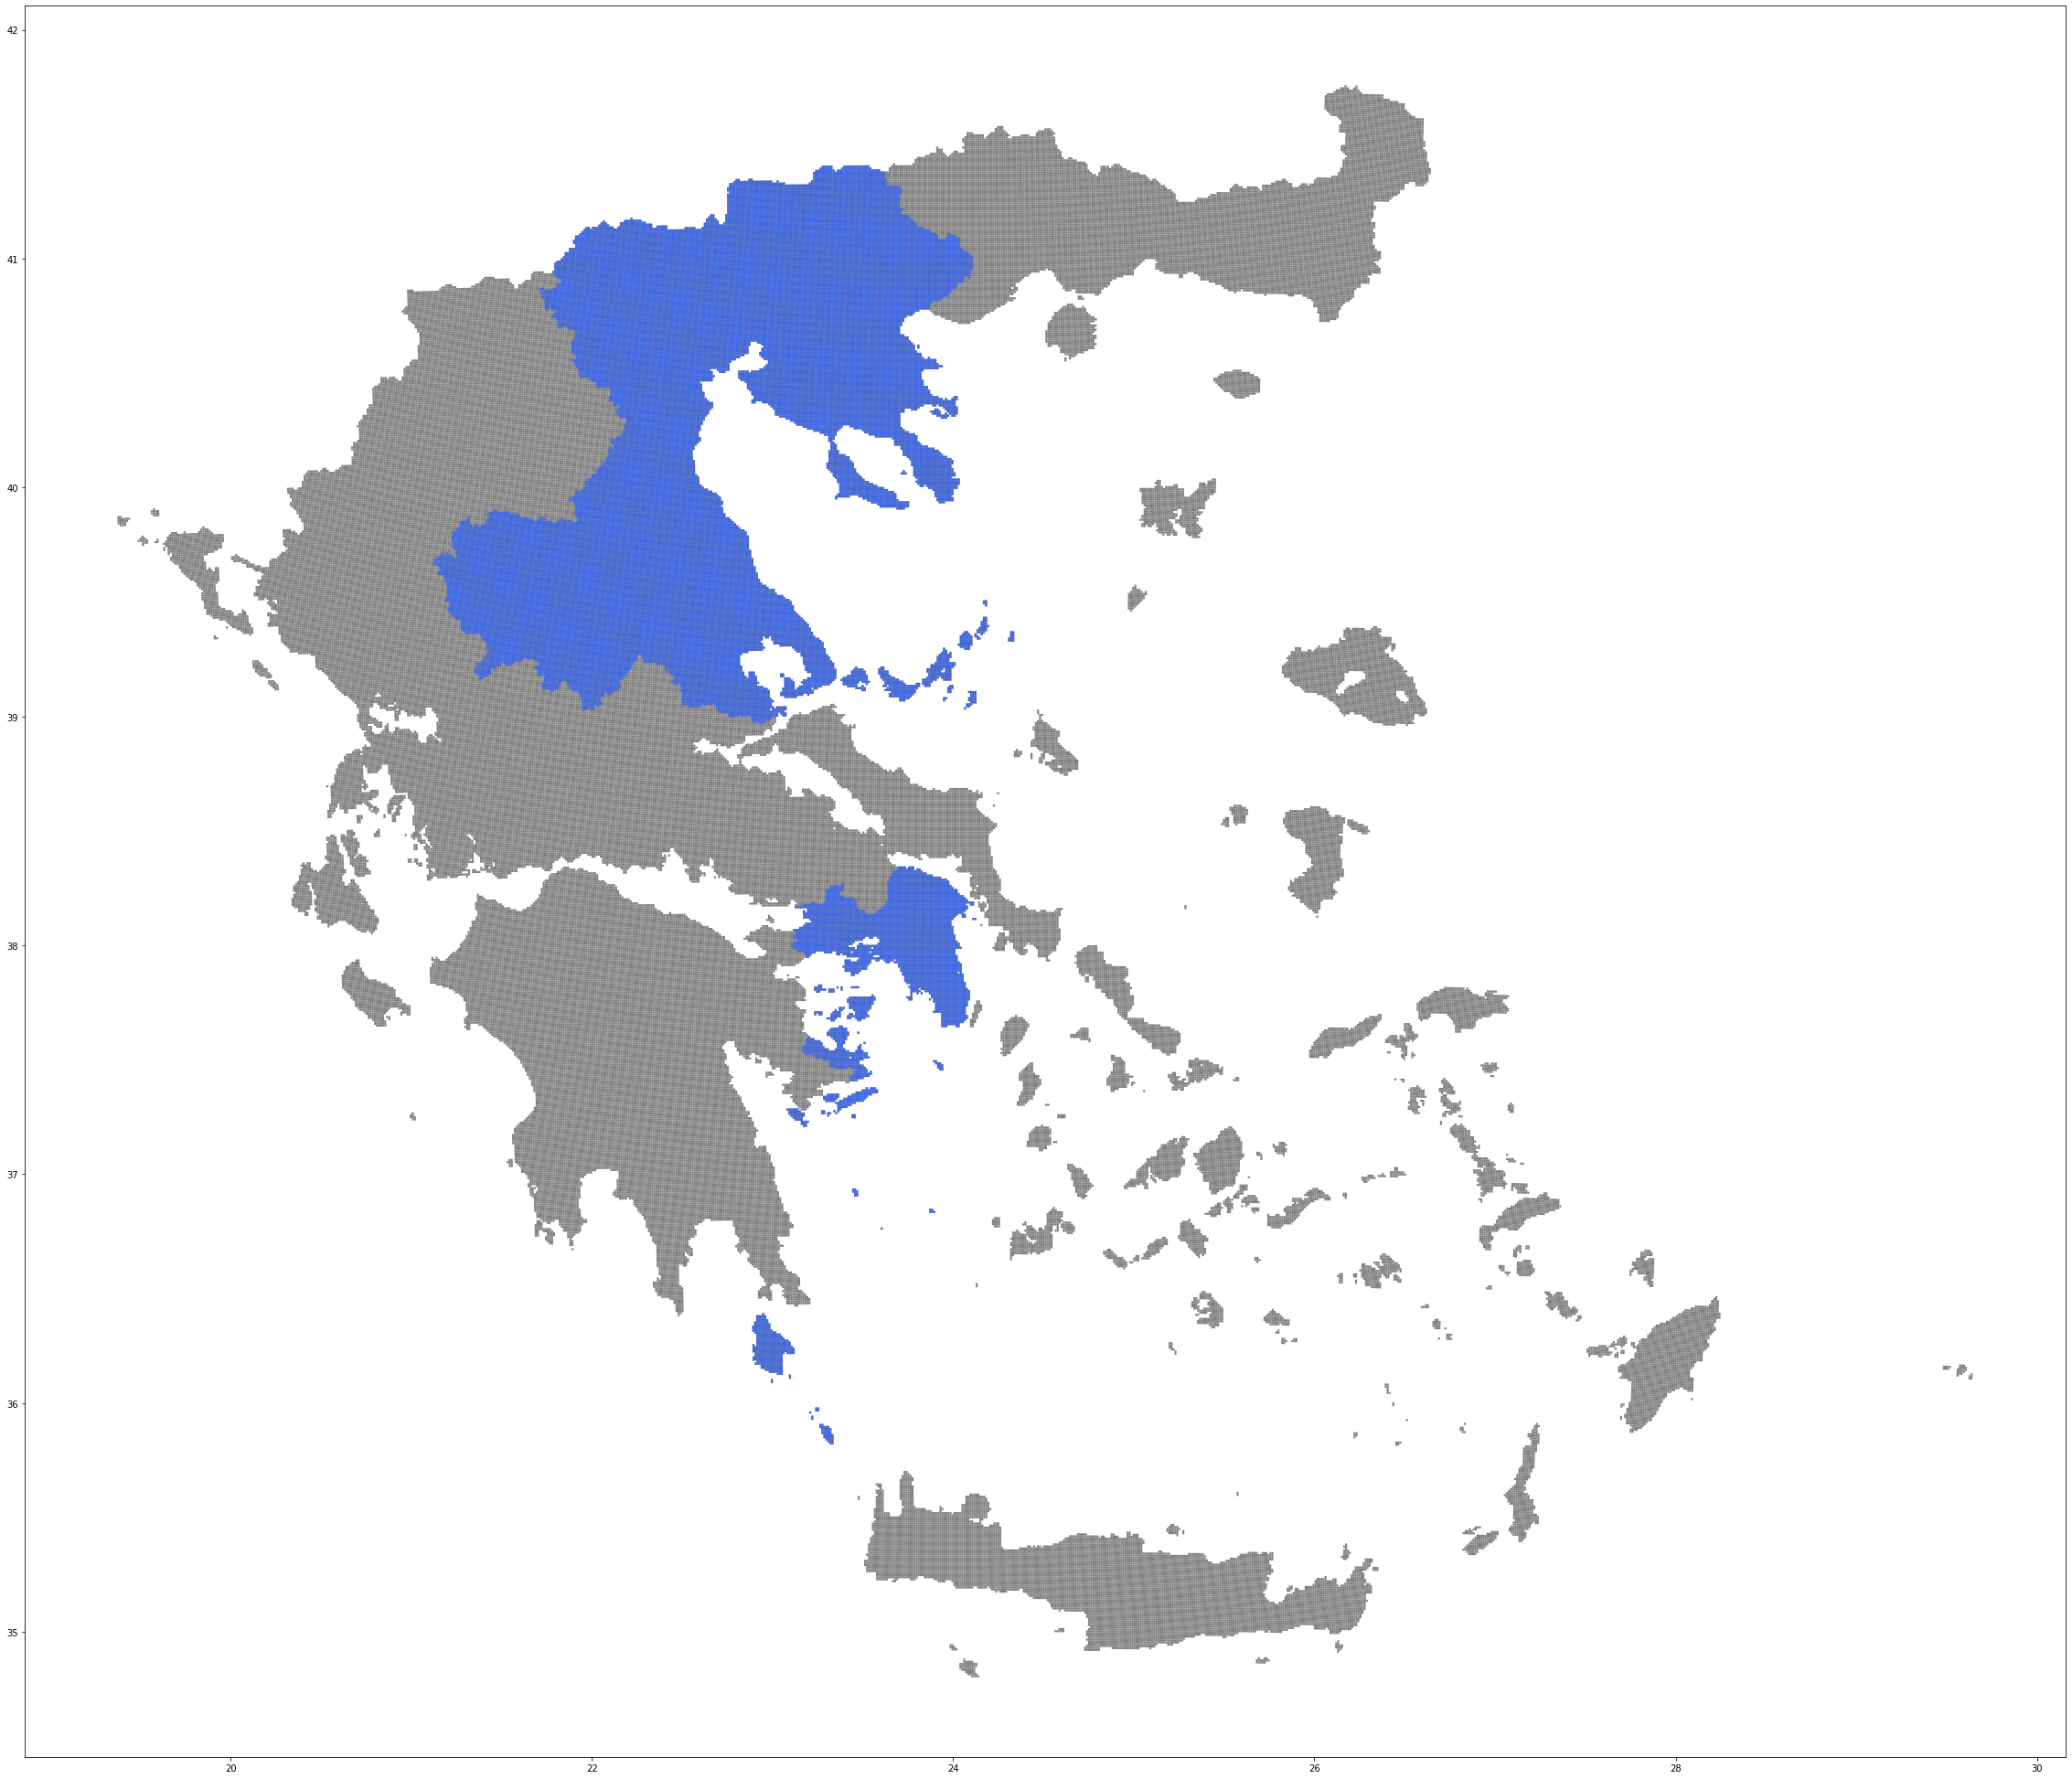

In [36]:
ax = greece_grid.plot(figsize=(40, 40), color='grey', facecolor = 'silver')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Έβρος'].plot(ax=ax, color='bisque', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Δράμα'].plot(ax=ax, color='darkorange', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ξάνθη'].plot(ax=ax, color='tan', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Σέρρες'].plot(ax=ax, color='ivory', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Σέρρες'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ροδόπη'].plot(ax=ax, color='lavender', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Κιλκίς'].plot(ax=ax, color='navy', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Κιλκίς'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Θάσος, Καβάλα'].plot(ax=ax, color='slateblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Πέλλα'].plot(ax=ax, color='plum', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Πέλλα'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Θεσσαλονίκη'].plot(ax=ax, color='cyan', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Θεσσαλονίκη'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Φλώρινα'].plot(ax=ax, color='coral', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Καστοριά'].plot(ax=ax, color='skyblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ημαθία'].plot(ax=ax, color='crimson', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Ημαθία'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Γρεβενά, Κοζάνη'].plot(ax=ax, color='cadetblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Χαλκιδική'].plot(ax=ax, color='fuchsia', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Χαλκιδική'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Πιερία'].plot(ax=ax, color='lime', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Πιερία'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ιωάννινα'].plot(ax=ax, color='aquamarine', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Λάρισα'].plot(ax=ax, color='yellow', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Λάρισα'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Λέσβος, Λήμνος'].plot(ax=ax, color='green', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Κέρκυρα'].plot(ax=ax, color='forestgreen', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Καρδίτσα, Τρίκαλα'].plot(ax=ax, color='orange', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Καρδίτσα, Τρίκαλα'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Θεσπρωτία'].plot(ax=ax, color='rosybrown', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Μαγνησία, Σποράδες'].plot(ax=ax, color='tomato', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Μαγνησία, Σποράδες'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Άρτα, Πρέβεζα'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ευρυτανία'].plot(ax=ax, color='deepskyblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Φθιώτιδα'].plot(ax=ax, color='violet', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Αιτωλοακαρνανία'].plot(ax=ax, color='pink', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Εύβοια'].plot(ax=ax, color='palegreen', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Λευκάδα'].plot(ax=ax, color='gold', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Φωκίδα'].plot(ax=ax, color='brown', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Χίος'].plot(ax=ax, color='lightgrey', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ιθάκη, Κεφαλληνία'].plot(ax=ax, color='black', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Βοιωτία'].plot(ax=ax, color='khaki', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Αχαΐα'].plot(ax=ax, color='blueviolet', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ανατολική Αττική'].plot(ax=ax, color='darkolivegreen', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Δυτική Αττική'].plot(ax=ax, color='moccasin', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Ανατολική Αττική'].plot(ax=ax, color='royalblue', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Δυτική Αττική'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Κορινθία'].plot(ax=ax, color='black', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Βόρειος Τομέας Αθηνών'].plot(ax=ax, color='mistyrose', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Δυτικός Τομέας Αθηνών'].plot(ax=ax, color='magenta', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Κεντρικός Τομέας Αθηνών'].plot(ax=ax, color='lawngreen', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Πειραιάς, Νήσοι'].plot(ax=ax, color='teal', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Βόρειος Τομέας Αθηνών'].plot(ax=ax, color='royalblue', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Δυτικός Τομέας Αθηνών'].plot(ax=ax, color='royalblue', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Κεντρικός Τομέας Αθηνών'].plot(ax=ax, color='royalblue', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Πειραιάς, Νήσοι'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Άνδρος, Θήρα, Κέα, Μήλος, Μύκονος, Νάξος, Πάρος, Σύρος, Τήνος'].plot(ax=ax, color='sienna', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ζάκυνθος'].plot(ax=ax, color='chocolate', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Νότιος Τομέας Αθηνών'].plot(ax=ax, color='darksalmon', facecolor = 'none')
greece_grid[greece_grid['NUTS3_NAME'] == 'Νότιος Τομέας Αθηνών'].plot(ax=ax, color='royalblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Αργολίδα, Αρκαδία'].plot(ax=ax, color='springgreen', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ικαρία, Σάμος'].plot(ax=ax, color='powderblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Κάλυμνος, Κάρπαθος – Ηρωική Νήσος Κάσος, Κως, Ρόδος'].plot(ax=ax, color='lightcyan', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Λακωνία, Μεσσηνία'].plot(ax=ax, color='turquoise', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Χανιά'].plot(ax=ax, color='aliceblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Λασίθι'].plot(ax=ax, color='steelblue', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ηράκλειο'].plot(ax=ax, color='hotpink', facecolor = 'none')
# greece_grid[greece_grid['NUTS3_NAME'] == 'Ρέθυμνο'].plot(ax=ax, color='honeydew', facecolor = 'none')


In [37]:
infected_cells = greece_wnv_cases.cell_code.unique().tolist()
len(infected_cells)

881

In [38]:
greece_grid['infected'] = 0
greece_grid.loc[greece_grid['cell_code'].isin(infected_cells), ['infected']] = 1

In [39]:
greece_grid.infected.sum()

881

<AxesSubplot:>

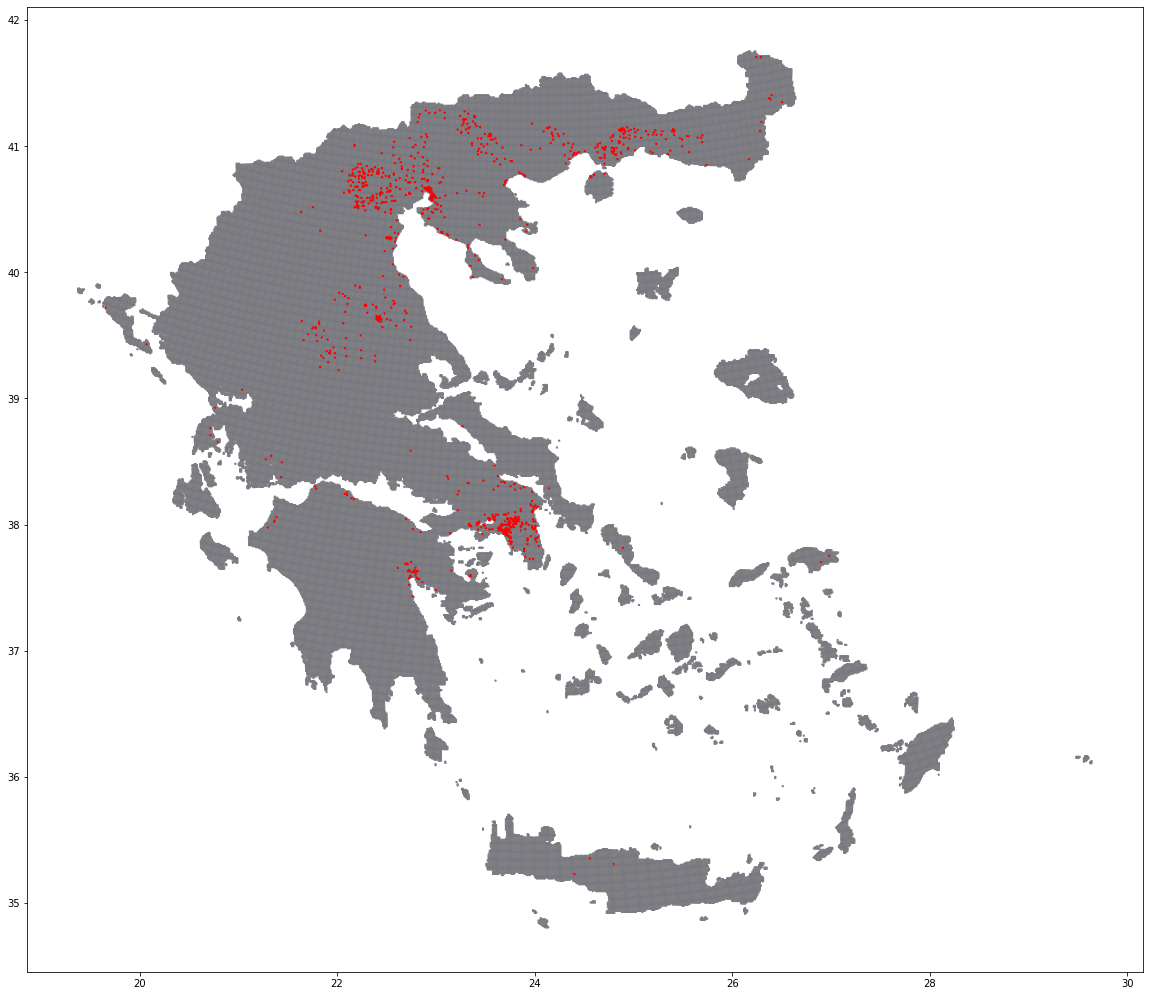

In [40]:
ax = greece_grid[greece_grid['infected'] == 0].plot(facecolor="none", edgecolor='grey', figsize=(20, 20), color='blue')
greece_grid[greece_grid['infected'] == 1].plot(facecolor="none", edgecolor='red', ax = ax, color='red')

In [41]:
infected_gdf = greece_grid[greece_grid['infected'] == 1]
non_infected_gdf = greece_grid[greece_grid['infected'] == 0]

centroids_infected = list(infected_gdf['centroid'].apply(lambda point: (point.x, point.y)))
centroids_non_infected = list(non_infected_gdf['centroid'].apply(lambda point: (point.x, point.y)))

In [47]:
all_non_infected = pd.DataFrame()

for point in centroids_infected:
    distances_matrix = euclidean_distances(np.array(centroids_non_infected), np.array(point).reshape(1, -1))
    sorted_indices = np.argsort(distances_matrix, axis=0)
    sorted_non_infected = non_infected_gdf.iloc[sorted_indices[:, 0]]
    top100_noninfected = sorted_non_infected.iloc[:100].sample(2, random_state = 1)
    rest_noninfected = sorted_non_infected.iloc[101:].sample(2, random_state = 1361)
    all_non_infected = all_non_infected.append(top100_noninfected)
    all_non_infected = all_non_infected.append(rest_noninfected)

<AxesSubplot:>

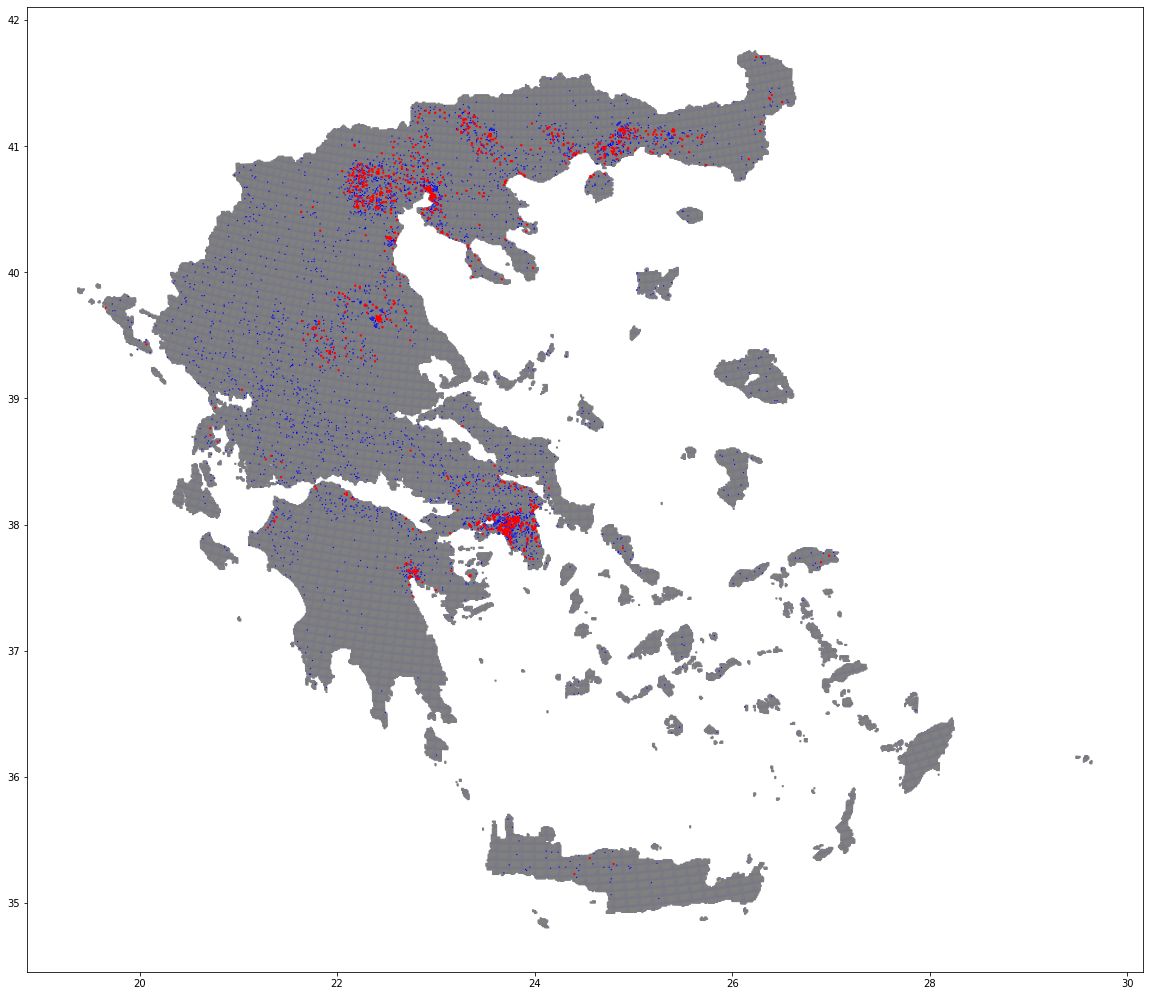

In [48]:
ax = greece_grid[greece_grid['infected'] == 0].plot(facecolor="none", edgecolor='grey', figsize=(20, 20), color='blue')
all_non_infected.plot(facecolor="none", edgecolor='none', ax = ax, color='blue')
infected_gdf.plot(facecolor="none", edgecolor='red', ax = ax, color='red')

In [52]:
wnv_grid = pd.concat([all_non_infected, infected_gdf])

In [53]:
wnv_grid

,cell_code,geometry,LAU1_NAME,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,centroid,infected
105,G588,"POLYGON ((26.29705 41.69166, 26.29737 41.70066...",Ορεστιάδας,EL5,Βόρεια Ελλάδα,EL51,"Aνατολική Μακεδονία, Θράκη",EL511,Έβρος,4.0,2.0,1.0,POINT (26.30322 41.69603),0
135,H588,"POLYGON ((26.29673 41.68266, 26.29705 41.69166...",Ορεστιάδας,EL5,Βόρεια Ελλάδα,EL51,"Aνατολική Μακεδονία, Θράκη",EL511,Έβρος,4.0,2.0,1.0,POINT (26.30290 41.68704),0
61878,JE196,"POLYGON ((21.66866 39.36697, 21.66836 39.37597...",Μουζακίου,EL6,Κεντρική Ελλάδα,EL61,Θεσσαλία,EL611,"Καρδίτσα, Τρίκαλα",2.0,3.0,3.0,POINT (21.67431 39.37159),0
97797,OO345,"POLYGON ((23.40853 38.12720, 23.40845 38.13622...",Μάνδρας - Ειδυλλίας,EL3,Αττική,EL30,Aττική,EL306,Δυτική Αττική,2.0,1.0,1.0,POINT (23.41420 38.13174),0
246,K591,"POLYGON ((26.33177 41.65493, 26.33210 41.66393...",Ορεστιάδας,EL5,Βόρεια Ελλάδα,EL51,"Aνατολική Μακεδονία, Θράκη",EL511,Έβρος,4.0,2.0,1.0,POINT (26.33794 41.65931),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114715,RI308,"POLYGON ((22.99525 37.47547, 22.99513 37.48449...",Ναυπλιέων,EL6,Κεντρική Ελλάδα,EL65,Πελοπόννησος,EL651,"Αργολίδα, Αρκαδία",3.0,3.0,1.0,POINT (23.00085 37.48003),1
115573,RN287,"POLYGON ((22.75854 37.42816, 22.75839 37.43717...",Βόρειας Κυνουρίας,EL6,Κεντρική Ελλάδα,EL65,Πελοπόννησος,EL651,"Αργολίδα, Αρκαδία",3.0,3.0,1.0,POINT (22.76412 37.43272),1
133796,AAK447,"POLYGON ((24.55205 35.35088, 24.55211 35.35989...",Ρεθύμνης,EL4,"Νησιά Αιγαίου, Κρήτη",EL43,Κρήτη,EL433,Ρέθυμνο,3.0,3.0,1.0,POINT (24.55758 35.35536),1
134742,AAP469,"POLYGON ((24.79372 35.30445, 24.79380 35.31347...",Μυλοποτάμου,EL4,"Νησιά Αιγαίου, Κρήτη",EL43,Κρήτη,EL433,Ρέθυμνο,3.0,3.0,1.0,POINT (24.79926 35.30892),1


In [54]:
process_greek(wnv_grid, 'NUTS1_NAME')
process_greek(wnv_grid, 'NUTS2_NAME')
process_greek(wnv_grid, 'NUTS3_NAME')
process_greek(wnv_grid, 'LAU1_NAME')

In [55]:
wnv_grid['x'] = wnv_grid['centroid'].apply(lambda point: point.x)
wnv_grid['y'] = wnv_grid['centroid'].apply(lambda point: point.y)

In [56]:
describe_dataframe(wnv_grid)

,Column,Missing
0,cell_code,0.0
1,geometry,0.0
2,LAU1_NAME,0.0
3,NUTS1_ID,0.0
4,NUTS1_NAME,0.0
5,NUTS2_ID,0.0
6,NUTS2_NAME,0.0
7,NUTS3_ID,0.0
8,NUTS3_NAME,0.0
9,MOUNT_TYPE,0.0


In [57]:
wnv_grid.NUTS1_NAME.unique().tolist()

['βορεια ελλαδα', 'κεντρικη ελλαδα', 'αττικη', 'νησια αιγαιου, κρητη']

In [58]:
wnv_grid.NUTS2_NAME.unique().tolist()

['aνατολικη μακεδονια, θρακη',
 'θεσσαλια',
 'aττικη',
 'στερεα ελλαδα',
 'νοτιο αιγαιο',
 'δυτικη μακεδονια',
 'πελοποννησος',
 'κεντρικη μακεδονια',
 'ηπειρος',
 'δυτικη ελλαδα',
 'βορειο αιγαιο',
 'ιονια νησια',
 'κρητη']

In [59]:
wnv_grid.NUTS3_NAME.unique().tolist()

['εβρος',
 'καρδιτσα, τρικαλα',
 'δυτικη αττικη',
 'φωκιδα',
 'ανατολικη αττικη',
 'καλυμνος, καρπαθος ηρωικη νησος κασος, κως, ροδος',
 'γρεβενα, κοζανη',
 'λαρισα',
 'αργολιδα, αρκαδια',
 'πειραιας, νησοι',
 'ανδρος, θηρα, κεα, μηλος, μυκονος, ναξος, παρος, συρος, τηνος',
 'μαγνησια, σποραδες',
 'κιλκις',
 'σερρες',
 'ευβοια',
 'ιωαννινα',
 'βοιωτια',
 'αρτα, πρεβεζα',
 'ευρυτανια',
 'θεσπρωτια',
 'ροδοπη',
 'αιτωλοακαρνανια',
 'φθιωτιδα',
 'λεσβος, λημνος',
 'δραμα',
 'ξανθη',
 'κορινθια',
 'ικαρια, σαμος',
 'καστορια',
 'φλωρινα',
 'βορειος τομεας αθηνων',
 'πελλα',
 'αχαια',
 'θασος, καβαλα',
 'ιθακη, κεφαλληνια',
 'χιος',
 'θεσσαλονικη',
 'κερκυρα',
 'λευκαδα',
 'ημαθια',
 'χαλκιδικη',
 'πιερια',
 'ηλεια',
 'λακωνια, μεσσηνια',
 'ζακυνθος',
 'ρεθυμνο',
 'χανια',
 'κεντρικος τομεας αθηνων',
 'δυτικος τομεας αθηνων',
 'ηρακλειο',
 'νοτιος τομεας αθηνων']

In [60]:
wnv_grid['NUTS2_NAME'] = wnv_grid['NUTS2_NAME'].apply(lambda x : x.replace('aνατολικη μακεδονια, θρακη','ανατολικη μακεδονια, θρακη'))
wnv_grid['NUTS2_NAME'] = wnv_grid['NUTS2_NAME'].apply(lambda x : x.replace('aττικη','αττικη'))

In [61]:
wnv_grid.NUTS2_NAME.unique().tolist()

['ανατολικη μακεδονια, θρακη',
 'θεσσαλια',
 'αττικη',
 'στερεα ελλαδα',
 'νοτιο αιγαιο',
 'δυτικη μακεδονια',
 'πελοποννησος',
 'κεντρικη μακεδονια',
 'ηπειρος',
 'δυτικη ελλαδα',
 'βορειο αιγαιο',
 'ιονια νησια',
 'κρητη']

In [62]:
wnv_grid.reset_index(drop= True, inplace = True)

In [63]:
wnv_grid.shape

(4405, 16)

In [64]:
columns = ['x', 'y', 'cell_code', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 
            'LAU1_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'geometry', 'centroid']

wnv_grid = wnv_grid[columns].copy()

In [65]:
wnv_grid.sort_values(by=['NUTS1_NAME', 'NUTS2_NAME', 'NUTS3_NAME', 'LAU1_NAME'], inplace = True)

<AxesSubplot:>

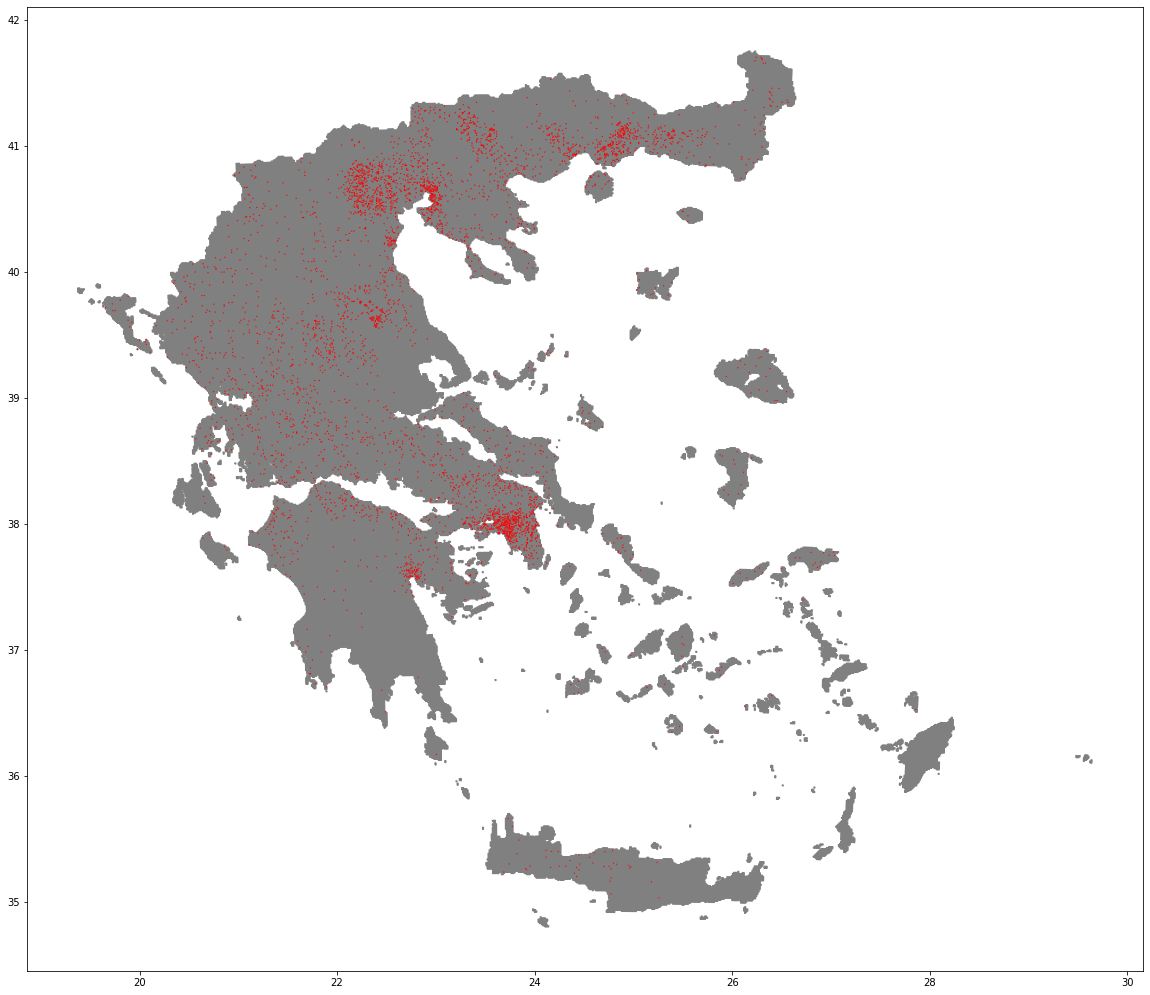

In [66]:
ax = greece_grid.plot(facecolor="none", edgecolor='grey', figsize=(20, 20), color='grey')
wnv_grid.plot(facecolor="none", edgecolor='none', ax = ax, color='red')

In [67]:
wnv_grid.reset_index(drop= True, inplace = True)

In [68]:
wnv_grid

,x,y,cell_code,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,centroid
0,23.722470,38.078795,OU372,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,αχαρνων,2.0,1.0,1.0,"POLYGON ((23.71679 38.07427, 23.71675 38.08329...",POINT (23.72247 38.07879)
1,23.756376,38.168996,OK375,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,αχαρνων,2.0,1.0,1.0,"POLYGON ((23.75068 38.16448, 23.75065 38.17349...",POINT (23.75638 38.16900)
2,23.767821,38.160007,OL376,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,αχαρνων,2.0,1.0,1.0,"POLYGON ((23.76213 38.15549, 23.76210 38.16450...",POINT (23.76782 38.16001)
3,23.813502,38.151076,OM380,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,αχαρνων,2.0,1.0,1.0,"POLYGON ((23.80781 38.14656, 23.80778 38.15557...",POINT (23.81350 38.15108)
4,23.779398,38.105953,OR377,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,αχαρνων,2.0,1.0,1.0,"POLYGON ((23.77371 38.10144, 23.77368 38.11045...",POINT (23.77940 38.10595)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4400,25.072809,37.632604,QR491,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL422,"ανδρος, θηρα, κεα, μηλος, μυκονος, ναξος, παρο...",τηνου,2.0,3.0,1.0,"POLYGON ((25.06708 37.62815, 25.06721 37.63716...",POINT (25.07281 37.63260)
4401,26.401059,36.639748,UV611,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,"καλυμνος, καρπαθος ηρωικη νησος κασος, κως, ροδος",αστυπαλαιας,2.0,2.0,1.0,"POLYGON ((26.39533 36.63536, 26.39561 36.64436...",POINT (26.40106 36.63975)
4402,26.130309,36.554768,VF587,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,"καλυμνος, καρπαθος ηρωικη νησος κασος, κως, ροδος",αστυπαλαιας,2.0,2.0,1.0,"POLYGON ((26.12460 36.55036, 26.12485 36.55937...",POINT (26.13031 36.55477)
4403,26.718755,37.398899,RO637,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,"καλυμνος, καρπαθος ηρωικη νησος κασος, κως, ροδος",πατμου,2.0,2.0,1.0,"POLYGON ((26.71295 37.39453, 26.71327 37.40353...",POINT (26.71875 37.39890)


In [69]:
wnv_grid.to_csv(f'../data/GR_Grid.csv', encoding=enc, index = False)